In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
ipl_auction_df = pd.read_csv( 'IPL IMB381IPL2013.xls' )

In [3]:
ipl_auction_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Sl.NO.         130 non-null    int64  
 1   PLAYER NAME    130 non-null    str    
 2   AGE            130 non-null    int64  
 3   COUNTRY        130 non-null    str    
 4   TEAM           130 non-null    str    
 5   PLAYING ROLE   130 non-null    str    
 6   T-RUNS         130 non-null    int64  
 7   T-WKTS         130 non-null    int64  
 8   ODI-RUNS-S     130 non-null    int64  
 9   ODI-SR-B       130 non-null    float64
 10  ODI-WKTS       130 non-null    int64  
 11  ODI-SR-BL      130 non-null    float64
 12  CAPTAINCY EXP  130 non-null    int64  
 13  RUNS-S         130 non-null    int64  
 14  HS             130 non-null    int64  
 15  AVE            130 non-null    float64
 16  SR-B           130 non-null    float64
 17  SIXERS         130 non-null    int64  
 18  RUNS-C         130 no

In [4]:
ipl_auction_df.iloc[0:5, 0:10]

,Sl.NO.,PLAYER NAME,AGE,COUNTRY,TEAM,PLAYING ROLE,T-RUNS,T-WKTS,ODI-RUNS-S,ODI-SR-B
0,1,"Abdulla, YA",2,SA,KXIP,Allrounder,0,0,0,0.00
1,2,Abdur Razzak,2,BAN,RCB,Bowler,214,18,657,71.41
2,3,"Agarkar, AB",2,IND,KKR,Bowler,571,58,1269,80.62
3,4,"Ashwin, R",1,IND,CSK,Bowler,284,31,241,84.56
4,5,"Badrinath, S",2,IND,CSK,Batsman,63,0,79,45.93


In [5]:
X_features = ipl_auction_df.columns

In [6]:
X_features = ['AGE', 'COUNTRY', 'PLAYING ROLE',
'T-RUNS', 'T-WKTS', 'ODI-RUNS-S', 'ODI-SR-B',
'ODI-WKTS', 'ODI-SR-BL', 'CAPTAINCY EXP', 'RUNS-S',
'HS', 'AVE', 'SR-B', 'SIXERS', 'RUNS-C', 'WKTS',
'AVE-BL', 'ECON', 'SR-BL']

In [7]:
ipl_auction_df['PLAYING ROLE'].unique()

<ArrowStringArray>
['Allrounder', 'Bowler', 'Batsman', 'W. Keeper']
Length: 4, dtype: str

In [8]:
pd.get_dummies(ipl_auction_df['PLAYING ROLE'])[0:5]

,Allrounder,Batsman,Bowler,W. Keeper
0,True,False,False,False
1,False,False,True,False
2,False,False,True,False
3,False,False,True,False
4,False,True,False,False


In [9]:
categorical_features = ['AGE', 'COUNTRY', 'PLAYING ROLE','CAPTAINCY EXP']

Encoding Categorical Features

In [10]:
ipl_auction_encoded_df = pd.get_dummies(ipl_auction_df[X_features],
columns = categorical_features,
drop_first = True)

In [11]:
ipl_auction_encoded_df.columns

Index(['T-RUNS', 'T-WKTS', 'ODI-RUNS-S', 'ODI-SR-B', 'ODI-WKTS', 'ODI-SR-BL',
       'RUNS-S', 'HS', 'AVE', 'SR-B', 'SIXERS', 'RUNS-C', 'WKTS', 'AVE-BL',
       'ECON', 'SR-BL', 'AGE_2', 'AGE_3', 'COUNTRY_BAN', 'COUNTRY_ENG',
       'COUNTRY_IND', 'COUNTRY_NZ', 'COUNTRY_PAK', 'COUNTRY_SA', 'COUNTRY_SL',
       'COUNTRY_WI', 'COUNTRY_ZIM', 'PLAYING ROLE_Batsman',
       'PLAYING ROLE_Bowler', 'PLAYING ROLE_W. Keeper', 'CAPTAINCY EXP_1'],
      dtype='str')

In [12]:
X_features = ipl_auction_encoded_df.columns
len(X_features)

31

In [14]:
%pip install statsmodels

   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.3 MB ? eta -:--:--
    --------------------------------------- 0.3/11.3 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.3 MB 1.4 MB/s eta 0:00:08
   -- ------------------------------------- 0.8/11.3 MB 1.4 MB/s eta 0:00:08
   --- ------------------------------------ 1.0/11.3 MB 1.5 MB/s eta 0:00:08
   ----- ---------------------------------- 1.6/11.3 MB 1.5 MB/s eta 0:00:07
   ------ --------------------------------- 1.8/11.3 MB 1.6 MB/s eta 0:00:06
   ------- -------------------------------- 2.1/11.3 MB 1.6 MB/s eta 0:00:06
   -------- ------------------------------- 2.4/11.3 MB 1.6 MB/s eta 0:00:06
   ---------- ----------------------------- 2.9/11.3 MB 1.6 MB/s eta 0:00:06
   ------------ --------------------------- 3.4/11.3 MB 1.7 MB/s eta 0:00:05
   -------------- ------------------------- 4.2/11.3 MB 1.9 MB/s eta 0:00:04
   -----------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
import statsmodels.api as sm
X = sm.add_constant( ipl_auction_encoded_df )

In [16]:
Y = ipl_auction_df['SOLD PRICE']

In [17]:
X = X.apply(lambda x: x.astype(int) if x.dtype == 'bool' else x)

In [18]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   const                   130 non-null    float64
 1   T-RUNS                  130 non-null    int64  
 2   T-WKTS                  130 non-null    int64  
 3   ODI-RUNS-S              130 non-null    int64  
 4   ODI-SR-B                130 non-null    float64
 5   ODI-WKTS                130 non-null    int64  
 6   ODI-SR-BL               130 non-null    float64
 7   RUNS-S                  130 non-null    int64  
 8   HS                      130 non-null    int64  
 9   AVE                     130 non-null    float64
 10  SR-B                    130 non-null    float64
 11  SIXERS                  130 non-null    int64  
 12  RUNS-C                  130 non-null    int64  
 13  WKTS                    130 non-null    int64  
 14  AVE-BL                  130 non-null    float64
 15  

Splitting the Dataset into Train and Validation Sets

In [19]:
from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split(X ,Y,train_size = 0.8,random_state = 42 )

In [20]:
train_X.info()
revised=train_X

<class 'pandas.DataFrame'>
Index: 104 entries, 70 to 102
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   const                   104 non-null    float64
 1   T-RUNS                  104 non-null    int64  
 2   T-WKTS                  104 non-null    int64  
 3   ODI-RUNS-S              104 non-null    int64  
 4   ODI-SR-B                104 non-null    float64
 5   ODI-WKTS                104 non-null    int64  
 6   ODI-SR-BL               104 non-null    float64
 7   RUNS-S                  104 non-null    int64  
 8   HS                      104 non-null    int64  
 9   AVE                     104 non-null    float64
 10  SR-B                    104 non-null    float64
 11  SIXERS                  104 non-null    int64  
 12  RUNS-C                  104 non-null    int64  
 13  WKTS                    104 non-null    int64  
 14  AVE-BL                  104 non-null    float64
 15  ECON

Building the Model on the Training Dataset

In [21]:
ipl_model_1 = sm.OLS(train_y, train_X).fit()


In [22]:
ipl_model_1.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                            Results: Ordinary least squares
========================================================================================
Model:                     OLS                     Adj. R-squared:            0.362     
Dependent Variable:        SOLD PRICE              AIC:                       2965.2841 
Date:                      2026-09-28 11:56        BIC:                       3049.9046 
No. Observations:          104                     Log-Likelihood:            -1450.6   
Df Model:                  31                      F-statistic:               2.883     
Df Residuals:              72                      Prob (F-statistic):        0.000114  
R-squared:                 0.554                   Scale:                     1.1034e+11
----------------------------------------------------------------------------------------
                          Coef.       Std.Err.     t    P>|t|     [0.025       0.975]   
----------------------------------------------------------------------------------------
const                   375827.1991 228849.9306  1.6422 0.1049  -80376.7997  832031.1978
T-RUNS                     -53.7890     32.7172 -1.6441 0.1045    -119.0096      11.4316
T-WKTS                    -132.5967    609.7525 -0.2175 0.8285   -1348.1162    1082.9228
ODI-RUNS-S                  57.9600     31.5071  1.8396 0.0700      -4.8482     120.7681
ODI-SR-B                  -524.1450   1576.6368 -0.3324 0.7405   -3667.1130    2618.8231
ODI-WKTS                   815.3944    832.3883  0.9796 0.3306    -843.9413    2474.7301
ODI-SR-BL                 -773.3092   1536.3334 -0.5033 0.6163   -3835.9338    2289.3154
RUNS-S                     114.7205    173.3088  0.6619 0.5101    -230.7643     460.2054
HS                       -5516.3354   2586.3277 -2.1329 0.0363  -10672.0855    -360.5853
AVE                      21560.2760   7774.2419  2.7733 0.0071    6062.6080   37057.9439
SR-B                     -1324.7218   1373.1303 -0.9647 0.3379   -4062.0071    1412.5635
SIXERS                    4264.1001   4089.6000  1.0427 0.3006   -3888.3685   12416.5687
RUNS-C                      69.8250    297.6697  0.2346 0.8152    -523.5687     663.2187
WKTS                      3075.2422   7262.4452  0.4234 0.6732  -11402.1778   17552.6622
AVE-BL                    5182.9335  10230.1581  0.5066 0.6140  -15210.5140   25576.3810
ECON                     -6820.7781  13109.3693 -0.5203 0.6045  -32953.8282   19312.2721
SR-BL                    -7658.8094  14041.8735 -0.5454 0.5871  -35650.7726   20333.1539
AGE_2                  -230767.6463 114117.2005 -2.0222 0.0469 -458256.1279   -3279.1648
AGE_3                  -216827.0808 152246.6232 -1.4242 0.1587 -520325.1773   86671.0156
COUNTRY_BAN            -122103.5196 438719.2796 -0.2783 0.7816 -996674.4196  752467.3803
COUNTRY_ENG             672410.7654 238386.2220  2.8207 0.0062  197196.5171 1147625.0136
COUNTRY_IND             155306.4011 126316.3449  1.2295 0.2229  -96500.6303  407113.4325
COUNTRY_NZ              194218.9120 173491.9293  1.1195 0.2667 -151630.9281  540068.7522
COUNTRY_PAK              75921.7670 193463.5545  0.3924 0.6959 -309740.7804  461584.3143
COUNTRY_SA               64283.3894 144587.6773  0.4446 0.6579 -223946.8775  352513.6564
COUNTRY_SL               17360.1530 176333.7497  0.0985 0.9218 -334154.7527  368875.0587
COUNTRY_WI               10607.7792 230686.7892  0.0460 0.9635 -449257.9304  470473.4887
COUNTRY_ZIM            -145494.4793 401505.2815 -0.3624 0.7181 -945880.6298  654891.6711
PLAYING ROLE_Batsman     75724.7643 150250.0240  0.5040 0.6158 -223793.1845  375242.7130
PLAYING ROLE_Bowler      15395.8752 126308.1272  0.1219 0.9033 -236394.7744  267186.5249
PLAYING ROLE_W. Keeper  -71358.6280 213585.7444 -0.3341 0.7393 -497134.0279  354416.7719
CAPTAINCY EXP_1         164113.3972 123430.6353  1.3296 0.1878  -81941.0773  410167.8717
----------------------------------------------------------------

In [23]:
train_X.info()

<class 'pandas.DataFrame'>
Index: 104 entries, 70 to 102
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   const                   104 non-null    float64
 1   T-RUNS                  104 non-null    int64  
 2   T-WKTS                  104 non-null    int64  
 3   ODI-RUNS-S              104 non-null    int64  
 4   ODI-SR-B                104 non-null    float64
 5   ODI-WKTS                104 non-null    int64  
 6   ODI-SR-BL               104 non-null    float64
 7   RUNS-S                  104 non-null    int64  
 8   HS                      104 non-null    int64  
 9   AVE                     104 non-null    float64
 10  SR-B                    104 non-null    float64
 11  SIXERS                  104 non-null    int64  
 12  RUNS-C                  104 non-null    int64  
 13  WKTS                    104 non-null    int64  
 14  AVE-BL                  104 non-null    float64
 15  ECON

Multi-Collinearity and Handling Multi-Collinearity

Variance Inflation Factor (VIF)

In [25]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def get_vif_factors( X ):
    X_matrix = X.to_numpy(dtype='float32')
    vif = [ variance_inflation_factor( X_matrix, i ) for i in range
    ( X_matrix.shape[1] ) ]
    vif_factors = pd.DataFrame()
    vif_factors['column'] = X.columns
    vif_factors['VIF'] = vif
    return vif_factors

In [26]:
vif_factors = get_vif_factors( X[X_features] )
vif_factors

,column,VIF
0,T-RUNS,8.809805
1,T-WKTS,6.393221
2,ODI-RUNS-S,11.011646
3,ODI-SR-B,1.673538
4,ODI-WKTS,6.979662
5,ODI-SR-BL,1.705721
6,RUNS-S,9.682279
7,HS,8.476796
8,AVE,6.651952
9,SR-B,2.238741


Checking Correlation of Columns with Large VIFs

In [27]:
columns_with_large_vif = vif_factors[vif_factors.VIF > 4].column

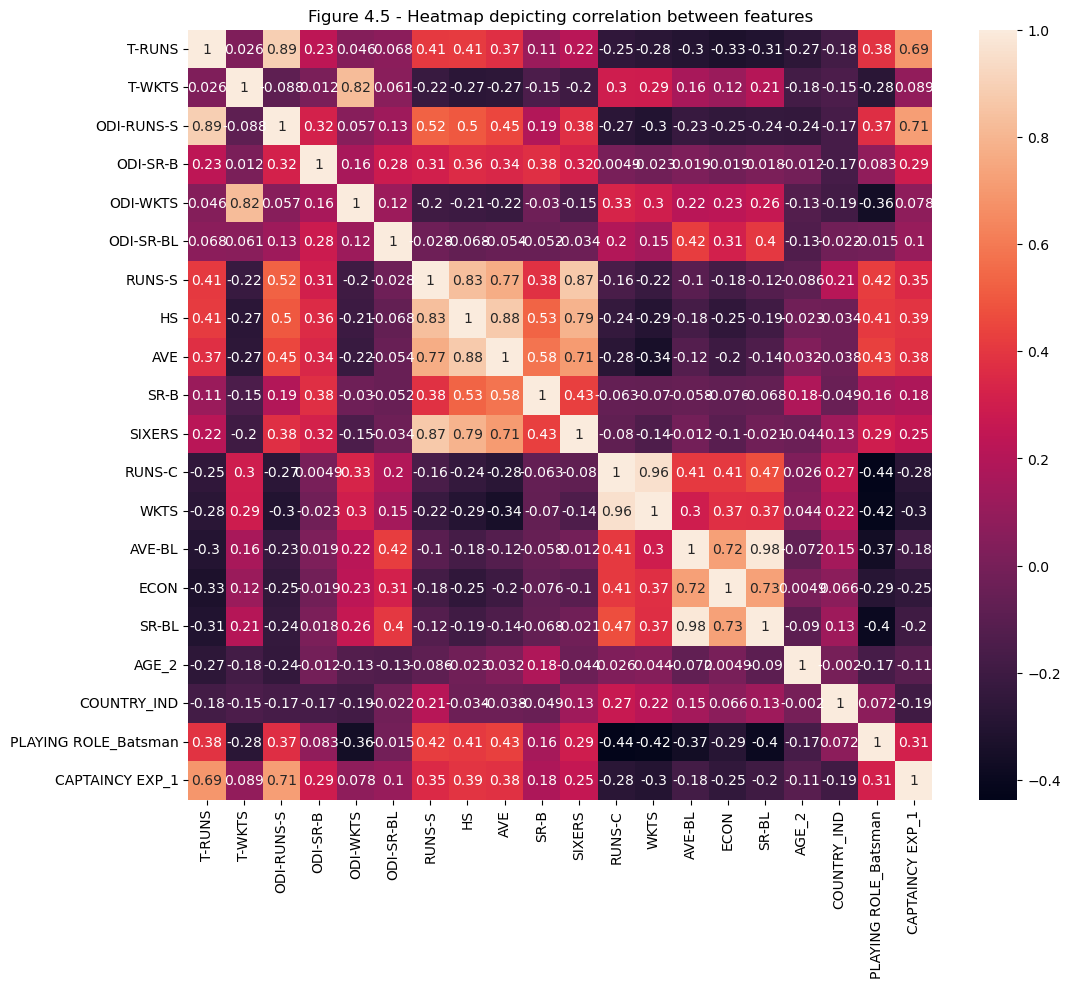

In [127]:
plt.figure( figsize = (12,10) )
sn.heatmap( X[columns_with_large_vif].corr(), annot = True );
plt.title("Figure 4.5 - Heatmap depicting correlation between features");

In [128]:
columns_to_be_removed = ['T-RUNS', 'T-WKTS', 'RUNS-S', 'HS', 'AVE','RUNS-C', 'SR-B', 'AVE-BL', 'ECON','ODI-SR-B', 'ODI-RUNS-S', 'AGE_2', 'SR-BL']

In [129]:
X_new_features = list( set(X_features) - set(columns_to_be_removed))

In [130]:
get_vif_factors( X[X_new_features] )

,column,VIF
0,ODI-WKTS,2.742890
1,COUNTRY_ZIM,1.205305
2,COUNTRY_NZ,1.173418
3,COUNTRY_SA,1.416656
4,AGE_3,1.779861
5,ODI-SR-BL,2.822148
6,PLAYING ROLE_Batsman,2.680207
7,COUNTRY_ENG,1.131870
8,COUNTRY_PAK,1.334773
9,PLAYING ROLE_Bowler,3.060168


Building a New Model after Removing Multi-collinearity

In [131]:
X_new_features

['ODI-WKTS',
 'COUNTRY_ZIM',
 'COUNTRY_NZ',
 'COUNTRY_SA',
 'AGE_3',
 'ODI-SR-BL',
 'PLAYING ROLE_Batsman',
 'COUNTRY_ENG',
 'COUNTRY_PAK',
 'PLAYING ROLE_Bowler',
 'COUNTRY_BAN',
 'WKTS',
 'COUNTRY_WI',
 'PLAYING ROLE_W. Keeper',
 'COUNTRY_IND',
 'SIXERS',
 'COUNTRY_SL',
 'CAPTAINCY EXP_1']

In [132]:
train_X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 104 entries, 70 to 102
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   const                   104 non-null    float64
 1   T-RUNS                  104 non-null    int64  
 2   T-WKTS                  104 non-null    int64  
 3   ODI-RUNS-S              104 non-null    int64  
 4   ODI-SR-B                104 non-null    float64
 5   ODI-WKTS                104 non-null    int64  
 6   ODI-SR-BL               104 non-null    float64
 7   RUNS-S                  104 non-null    int64  
 8   HS                      104 non-null    int64  
 9   AVE                     104 non-null    float64
 10  SR-B                    104 non-null    float64
 11  SIXERS                  104 non-null    int64  
 12  RUNS-C                  104 non-null    int64  
 13  WKTS                    104 non-null    int64  
 14  AVE-BL                  104 non-null    float6

In [133]:
print(type(X_new_features))

<class 'list'>


In [134]:
train_X = revised[X_new_features]

In [136]:
ipl_model_2 = sm.OLS(train_y, train_X).fit()
ipl_model_2.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                            Results: Ordinary least squares
========================================================================================
Model:                      OLS                Adj. R-squared (uncentered):   0.728     
Dependent Variable:         SOLD PRICE         AIC:                           2965.1080 
Date:                       2025-09-21 12:13   BIC:                           3012.7070 
No. Observations:           104                Log-Likelihood:                -1464.6   
Df Model:                   18                 F-statistic:                   16.49     
Df Residuals:               86                 Prob (F-statistic):            1.13e-20  
R-squared (uncentered):     0.775              Scale:                         1.2071e+11
----------------------------------------------------------------------------------------
                          Coef.       Std.Err.     t    P>|t|     [0.025       0.975]   
----------------------------------------------------------------------------------------
ODI-WKTS                   772.4088    470.6354  1.6412 0.1044    -163.1834    1708.0009
COUNTRY_ZIM             -67977.6781 390859.9289 -0.1739 0.8623 -844981.5007  709026.1445
COUNTRY_NZ              142968.8843 151841.7382  0.9416 0.3491 -158882.5009  444820.2695
COUNTRY_SA              108735.9086 115092.9596  0.9448 0.3474 -120061.3227  337533.1399
AGE_3                    -8950.6659  98041.9325 -0.0913 0.9275 -203851.5772  185950.2454
ODI-SR-BL                  909.0021   1267.4969  0.7172 0.4752   -1610.6983    3428.7026
PLAYING ROLE_Batsman    121382.0570 106685.0356  1.1378 0.2584  -90700.7746  333464.8886
COUNTRY_ENG             682934.7166 216150.8279  3.1595 0.0022  253241.0920 1112628.3411
COUNTRY_PAK             122810.2480 159600.8063  0.7695 0.4437 -194465.6542  440086.1502
PLAYING ROLE_Bowler     -18315.4968 106035.9664 -0.1727 0.8633 -229108.0215  192477.0279
COUNTRY_BAN            -108758.6040 369274.1916 -0.2945 0.7691 -842851.4010  625334.1930
WKTS                      2431.8988   2105.3524  1.1551 0.2512   -1753.4033    6617.2008
COUNTRY_WI              -22234.9315 213050.5847 -0.1044 0.9171 -445765.4766  401295.6135
PLAYING ROLE_W. Keeper  -55121.9240 169922.5271 -0.3244 0.7464 -392916.7281  282672.8801
COUNTRY_IND             282829.8091  96188.0292  2.9404 0.0042   91614.3356  474045.2827
SIXERS                    7862.1259   2086.6101  3.7679 0.0003    3714.0824   12010.1694
COUNTRY_SL               55912.3398 142277.1829  0.3930 0.6953 -226925.3388  338750.0184
CAPTAINCY EXP_1         208376.6957  98128.0284  2.1235 0.0366   13304.6314  403448.7600
----------------------------------------------------------------------------------------
Omnibus:                       8.635               Durbin-Watson:                  2.252
Prob(Omnibus):                 0.013               Jarque-Bera (JB):               8.345
Skew:                          0.623               Prob(JB):                       0.015
Kurtosis:                      3.609               Condition No.:                  1492 
========================================================================================
Notes:
[1] R² is computed without centering (uncentered) since the                 model does
not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly
specified.
[3] The condition number is large, 1.49e+03. This might indicate                that
there are strong multicollinearity or other numerical                problems.
"""

In [138]:
significant_vars = ['COUNTRY_IND', 'COUNTRY_ENG', 'SIXERS','CAPTAINCY EXP_1']
train_X = train_X[significant_vars]
ipl_model_3 = sm.OLS(train_y, train_X).fit()
ipl_model_3.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                        Results: Ordinary least squares
================================================================================
Model:                  OLS              Adj. R-squared (uncentered): 0.704     
Dependent Variable:     SOLD PRICE       AIC:                         2961.8089 
Date:                   2025-09-21 12:14 BIC:                         2972.3864 
No. Observations:       104              Log-Likelihood:              -1476.9   
Df Model:               4                F-statistic:                 62.77     
Df Residuals:           100              Prob (F-statistic):          1.97e-26  
R-squared (uncentered): 0.715            Scale:                       1.3164e+11
--------------------------------------------------------------------------------
                     Coef.      Std.Err.    t    P>|t|     [0.025      0.975]   
--------------------------------------------------------------------------------
COUNTRY_IND       387890.2538  63007.1511 6.1563 0.0000 262885.8606  512894.6471
COUNTRY_ENG       731833.6386 214164.4988 3.4172 0.0009 306937.3727 1156729.9045
SIXERS              8637.8344   1675.1313 5.1565 0.0000   5314.4216   11961.2472
CAPTAINCY EXP_1   359725.2741  74930.3460 4.8008 0.0000 211065.6018  508384.9463
--------------------------------------------------------------------------------
Omnibus:                   1.130             Durbin-Watson:                2.238
Prob(Omnibus):             0.568             Jarque-Bera (JB):             0.874
Skew:                      0.223             Prob(JB):                     0.646
Kurtosis:                  3.046             Condition No.:                165  
================================================================================
Notes:
[1] R² is computed without centering (uncentered) since the
model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly
specified.
"""

In [139]:
def draw_pp_plot( model, title ):
    probplot = sm.ProbPlot( model.resid );
    plt.figure( figsize = (8, 6) );
    probplot.ppplot( line='45' );
    plt.title( title );
    plt.show();

<Figure size 800x600 with 0 Axes>

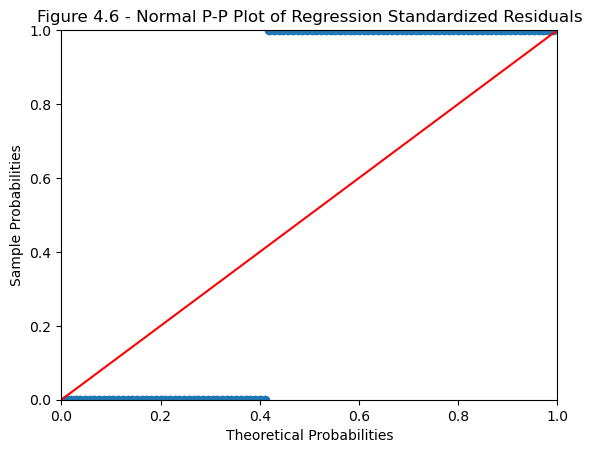

In [140]:
draw_pp_plot(ipl_model_3,"Figure 4.6 - Normal P-P Plot of Regression Standardized Residuals");

Residual Plot for Homoscedasticity and Model Specification

In [141]:
def plot_resid_fitted(fitted, resid, title):
    plt.scatter( get_standardized_values( fitted ),
    get_standardized_values( resid ) )
    plt.title(title)
    plt.xlabel("Standardized predicted values")
    plt.ylabel("Standardized residual values")
    plt.show()

In [142]:
def get_standardized_values( vals ):
    return (vals - vals.mean())/vals.std()

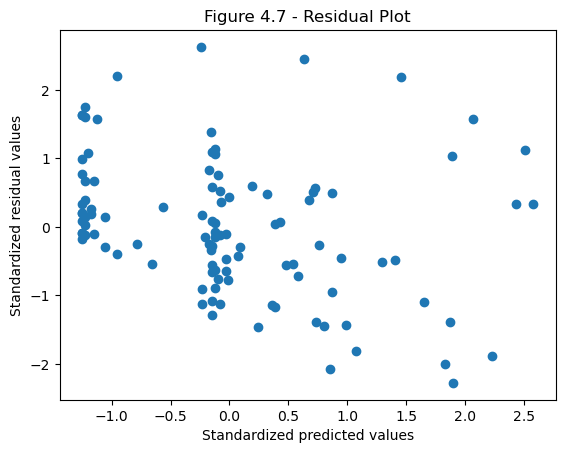

In [143]:
plot_resid_fitted(ipl_model_3.fittedvalues,ipl_model_3.resid,"Figure 4.7 - Residual Plot")

 Detecting Influencers

In [144]:
k = train_X.shape[1]
n = train_X.shape[0]

In [145]:
print("Number of variables:", k, " and number of observations:", n)

Number of variables: 4  and number of observations: 104


In [146]:
leverage_cutoff = 3*((k + 1)/n)
print( "Cutoff for leverage value:", round(leverage_cutoff, 3) )

Cutoff for leverage value: 0.144


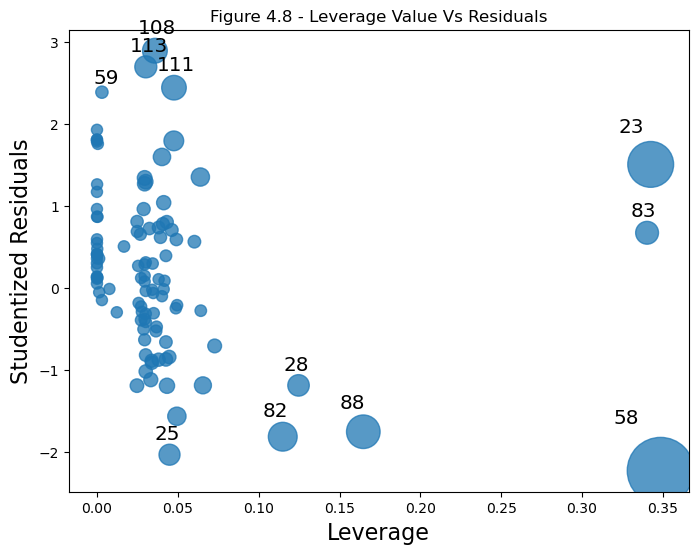

In [147]:
from statsmodels.graphics.regressionplots import influence_plot
fig, ax = plt.subplots( figsize=(8,6) )
influence_plot(ipl_model_3, ax = ax )
plt.title( "Figure 4.8 - Leverage Value Vs Residuals" )
plt.show()

In [149]:
ipl_auction_df[ipl_auction_df.index.isin( [23, 58, 83] )]

,Sl.NO.,PLAYER NAME,AGE,COUNTRY,TEAM,PLAYING ROLE,T-RUNS,T-WKTS,ODI-RUNS-S,ODI-SR-B,...,SR-B,SIXERS,RUNS-C,WKTS,AVE-BL,ECON,SR-BL,AUCTION YEAR,BASE PRICE,SOLD PRICE
23,24,"Flintoff, A",2,ENG,CSK,Allrounder,3845,226,3394,88.82,...,116.98,2,105,2,52.50,9.55,33.00,2009,950000,1550000
58,59,"Mascarenhas, AD",2,ENG,RR+,Allrounder,0,0,245,95.33,...,101.37,1,331,19,17.42,7.01,14.95,2011,100000,100000
83,84,"Pietersen, KP",2,ENG,RCB+,Batsman,6654,5,4184,86.76,...,141.20,30,215,7,30.71,7.41,24.86,2009,1350000,1550000


In [150]:
train_X_new = train_X.drop([23, 58, 83], axis = 0)
train_y_new = train_y.drop([23, 58, 83], axis = 0)

In [151]:
import numpy as np
train_y = np.sqrt(train_y)

In [152]:
ipl_model_4 = sm.OLS(train_y, train_X).fit()
ipl_model_4.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                        Results: Ordinary least squares
================================================================================
Model:                  OLS              Adj. R-squared (uncentered): 0.741     
Dependent Variable:     SOLD PRICE       AIC:                         1527.9999 
Date:                   2024-11-21 15:57 BIC:                         1538.5775 
No. Observations:       104              Log-Likelihood:              -760.00   
Df Model:               4                F-statistic:                 75.29     
Df Residuals:           100              Prob (F-statistic):          2.63e-29  
R-squared (uncentered): 0.751            Scale:                       1.3550e+05
-----------------------------------------------------------------------------------
                    Coef.      Std.Err.      t       P>|t|      [0.025      0.975] 
-----------------------------------------------------------------------------------
COUNTRY_IND        490.7089     63.9238    7.6765    0.0000    363.8860    617.5318
COUNTRY_ENG        563.0261    217.2801    2.5912    0.0110    131.9486    994.1036
SIXERS               8.5338      1.6995    5.0213    0.0000      5.1620     11.9055
CAPTAINCY EXP_1    417.7575     76.0204    5.4953    0.0000    266.9352    568.5799
--------------------------------------------------------------------------------
Omnibus:                   0.017             Durbin-Watson:                1.879
Prob(Omnibus):             0.992             Jarque-Bera (JB):             0.145
Skew:                      0.005             Prob(JB):                     0.930
Kurtosis:                  2.817             Condition No.:                165  
================================================================================
Notes:
[1] R² is computed without centering (uncentered) since the
model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly
specified.
"""

<Figure size 800x600 with 0 Axes>

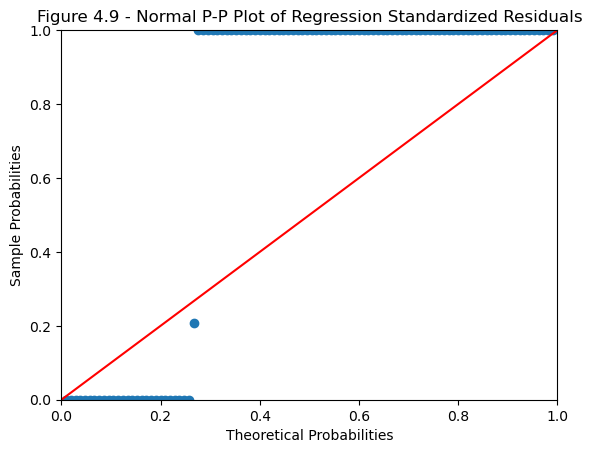

In [153]:
draw_pp_plot(ipl_model_4,"Figure 4.9 - Normal P-P Plot of Regression Standardized Residuals");

In [154]:
pred_y = np.power(ipl_model_4.predict(test_X[train_X.columns]),2)

In [155]:
from sklearn import metrics
np.sqrt(metrics.mean_squared_error(pred_y, test_y))

496151.18122558173

In [156]:
np.round( metrics.r2_score(pred_y, test_y), 2 )

0.44

In [ ]:
plt.figure( figsize = ( 8, 6 )) ## Creating a bar plot
sn.barplot(x="coef", y="columns", data=sorted_coef_vals);
plt.xlabel(“Coefficients from Linear Regression”)
plt.ylabel(“Features”)


In [ ]:
from sklearn import metrics
# Takes a model as a parameter
# Prints the RMSE on train and test set
def get_train_test_rmse( model ):
    # Predicting on training dataset
    y_train_pred = model.predict( X_train )
    # Compare the actual y with predicted y in the training dataset
    rmse_train = round(np.sqrt(metrics.mean_squared_error( y_train,y_train_pred)),3)
    # Predicting on test dataset
    y_test_pred = model.predict( X_test )
    # Compare the actual y with predicted y in the test dataset
    rmse_test = round(np.sqrt(metrics.mean_squared_error(  y_test,y_test_pred)),3)
    print( “train: ”, rmse_train, “ test:”, rmse_test )

In [ ]:
get_train_test_rmse( linreg )